In [93]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


df = pd.read_csv("Datasets/final_dataset.csv").dropna()


audio_cols = ['danceability', 'tempo', 'acousticness', 'speechiness', 'liveness',
              'instrumentalness', 'duration_ms', 'key', 'mode', 'loudness']
genre_cols = [col for col in df.columns if col.startswith("playlist_subgenre_")]
cover_cols = ['avg_r', 'avg_g', 'avg_b', 'dm_r', 'dm_g', 'dm_b', 'edge_c', 'face',
              'h_mean', 's_mean', 'v_mean', 'colorfulness']
lyrics_cols = [str(i) for i in range(384)]

# 🎧 Audio + Genre
X_audio = df[audio_cols + genre_cols]
# 🎨 Cover
X_color = df[cover_cols]
# 📝 Lyrics
X_lyrics = df[lyrics_cols]

y = df['mood']

# 🔀 Split
X_audio_train, X_audio_test, y_train, y_test = train_test_split(X_audio, y, test_size=0.2, stratify=y, random_state=42)
X_color_train, X_color_test = train_test_split(X_color, test_size=0.2, stratify=y, random_state=42)[0:2]
X_lyrics_train, X_lyrics_test = train_test_split(X_lyrics, test_size=0.2, stratify=y, random_state=42)[0:2]

# 🔢 Label encode
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

In [100]:
from sklearn.utils.class_weight import compute_sample_weight

# ==================== AUDIO + GENRE ====================
sample_weights_audio = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

xgb_audio = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    subsample=1.0,
    n_estimators=200,
    min_child_weight=1,
    max_depth=10,
    learning_rate=0.2,
    gamma=0,
    colsample_bytree=0.6
)

xgb_audio.fit(X_audio_train, y_train_encoded, sample_weight=sample_weights_audio)
pred_audio = xgb_audio.predict(X_audio_test)

print("🎧 AUDIO + GENRE (with class weights)")
print("✅ Accuracy:", accuracy_score(y_test_encoded, pred_audio))
print(classification_report(y_test_encoded, pred_audio, target_names=le.classes_))

🎧 AUDIO + GENRE (with class weights)
✅ Accuracy: 0.6610953972743636
              precision    recall  f1-score   support

        Calm       0.46      0.29      0.36       201
   Energetic       0.70      0.74      0.72      1900
         Sad       0.59      0.58      0.58       391
    Stressed       0.65      0.62      0.64      1397

    accuracy                           0.66      3889
   macro avg       0.60      0.56      0.57      3889
weighted avg       0.66      0.66      0.66      3889



In [97]:
#==================== LYRICS ====================

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 🎯 Lyrics için sample weight hesapla
sample_weights_lyrics = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

# 🔧 En iyi parametrelerle XGBoost modeli
xgb_lyrics = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    subsample=0.8,
    n_estimators=300,
    min_child_weight=5,
    max_depth=10,
    learning_rate=0.01,
    gamma=0.2,
    colsample_bytree=1.0
)

# 🚀 Modeli eğit
xgb_lyrics.fit(X_lyrics_train, y_train_encoded, sample_weight=sample_weights_lyrics)

# 🔍 Tahmin yap
pred_lyrics = xgb_lyrics.predict(X_lyrics_test)

# 🧾 Sonuçları yazdır
print("📝 LYRICS (Tuned XGBoost with Sample Weight)")
print("✅ Accuracy:", accuracy_score(y_test_encoded, pred_lyrics))
print("\n📊 Classification Report:")
print(classification_report(y_test_encoded, pred_lyrics, target_names=le.classes_))



📝 LYRICS (Tuned XGBoost with Sample Weight)
✅ Accuracy: 0.5173566469529443

📊 Classification Report:
              precision    recall  f1-score   support

        Calm       0.36      0.02      0.04       201
   Energetic       0.59      0.64      0.61      1900
         Sad       0.21      0.11      0.14       391
    Stressed       0.47      0.53      0.50      1397

    accuracy                           0.52      3889
   macro avg       0.41      0.33      0.32      3889
weighted avg       0.49      0.52      0.50      3889



In [96]:
# ------------------- COLOUR -------------------
sample_weights_colour = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

rf_color = RandomForestClassifier(
    n_estimators=360,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)
rf_color.fit(X_color_train, y_train_encoded, sample_weights_colour)
pred_color = rf_color.predict(X_color_test)
print("\n🎨 COLOUR FEATURES")
print("✅ Accuracy:", accuracy_score(y_test_encoded, pred_color))
print(classification_report(y_test_encoded, pred_color, target_names=le.classes_))


🎨 COLOUR FEATURES
✅ Accuracy: 0.4849575726407817
              precision    recall  f1-score   support

        Calm       0.17      0.15      0.16       201
   Energetic       0.61      0.50      0.55      1900
         Sad       0.21      0.25      0.23       391
    Stressed       0.47      0.57      0.52      1397

    accuracy                           0.48      3889
   macro avg       0.37      0.37      0.37      3889
weighted avg       0.50      0.48      0.49      3889



LOGISTIC REGRESSION

In [101]:
# ------------------- LATE FUSION -------------------
fusion_test = np.vstack([pred_audio, pred_color, pred_lyrics]).T
fusion_train = np.vstack([
    xgb_audio.predict(X_audio_train),
    rf_color.predict(X_color_train),
    xgb_lyrics.predict(X_lyrics_train)
]).T

meta_model = LogisticRegression(max_iter=300, random_state=42)
meta_model.fit(fusion_train, y_train_encoded)
fusion_pred = meta_model.predict(fusion_test)

print("\n🔗 LATE FUSION (LOGISTIC REGRESSION)")
print("✅ Accuracy:", accuracy_score(y_test_encoded, fusion_pred))
print("\n🧾 Classification Report:")
print(classification_report(y_test_encoded, fusion_pred, target_names=le.classes_))


🔗 LATE FUSION (LOGISTIC REGRESSION)
✅ Accuracy: 0.651581383389046

🧾 Classification Report:
              precision    recall  f1-score   support

        Calm       0.50      0.01      0.02       201
   Energetic       0.67      0.76      0.71      1900
         Sad       0.57      0.58      0.58       391
    Stressed       0.65      0.62      0.64      1397

    accuracy                           0.65      3889
   macro avg       0.60      0.49      0.48      3889
weighted avg       0.64      0.65      0.63      3889



RANDOM FOREST (BEST PARAMETERS RANDOMIZED SEARCH)

Fitting 3 folds for each of 60 candidates, totalling 180 fits

🔗 LATE FUSION (RANDOM FOREST)
✅ Best Parameters: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 171}
✅ Accuracy: 0.6328104911288249

📊 Classification Report:
              precision    recall  f1-score   support

        Calm       0.60      0.01      0.03       201
   Energetic       0.62      0.78      0.69      1900
         Sad       0.69      0.27      0.39       391
    Stressed       0.65      0.62      0.64      1397

    accuracy                           0.63      3889
   macro avg       0.64      0.42      0.44      3889
weighted avg       0.64      0.63      0.61      3889



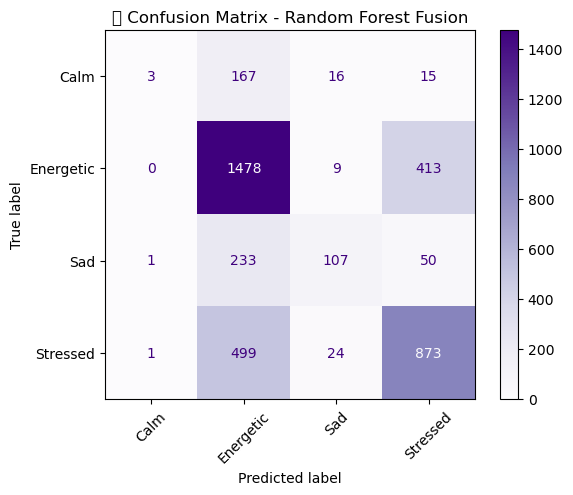

In [102]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from scipy.stats import randint
import numpy as np


param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


rf_meta = RandomForestClassifier(random_state=42, class_weight='balanced')


random_search = RandomizedSearchCV(
    estimator=rf_meta,
    param_distributions=param_dist,
    n_iter=60,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
    random_state=42
)


random_search.fit(fusion_train, y_train_encoded)

best_rf_meta = random_search.best_estimator_
fusion_pred = best_rf_meta.predict(fusion_test)


print("\n🔗 LATE FUSION (RANDOM FOREST)")
print("✅ Best Parameters:", random_search.best_params_)
print("✅ Accuracy:", accuracy_score(y_test_encoded, fusion_pred))

print("\n📊 Classification Report:")
print(classification_report(y_test_encoded, fusion_pred, target_names=le.classes_))

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


disp = ConfusionMatrixDisplay.from_predictions(
    y_test_encoded, fusion_pred, display_labels=le.classes_, cmap='Purples', xticks_rotation=45
)
plt.title("🎯 Confusion Matrix - Random Forest Fusion")
plt.show()


RANDOM FOREST BEST PRAMETERS(GRID SEARCH)

Fitting 3 folds for each of 72 candidates, totalling 216 fits

🔗 LATE FUSION (RANDOM FOREST - GRID SEARCH)
✅ Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
✅ Accuracy: 0.6328104911288249

📊 Classification Report:
              precision    recall  f1-score   support

        Calm       0.60      0.01      0.03       201
   Energetic       0.62      0.78      0.69      1900
         Sad       0.69      0.27      0.39       391
    Stressed       0.65      0.62      0.64      1397

    accuracy                           0.63      3889
   macro avg       0.64      0.42      0.44      3889
weighted avg       0.64      0.63      0.61      3889



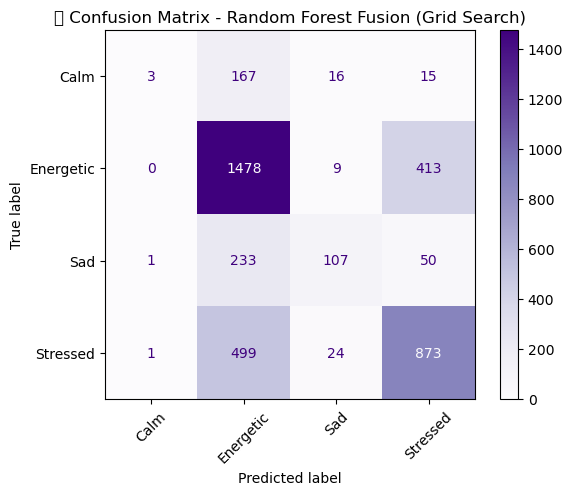

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}


rf_meta = RandomForestClassifier(random_state=42, class_weight='balanced')


grid_search = GridSearchCV(
    estimator=rf_meta,
    param_grid=param_grid,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)


grid_search.fit(fusion_train, y_train_encoded)


best_rf_meta = grid_search.best_estimator_
fusion_pred = best_rf_meta.predict(fusion_test)


print("\n🔗 LATE FUSION (RANDOM FOREST - GRID SEARCH)")
print("✅ Best Parameters:", grid_search.best_params_)
print("✅ Accuracy:", accuracy_score(y_test_encoded, fusion_pred))

print("\n📊 Classification Report:")
print(classification_report(y_test_encoded, fusion_pred, target_names=le.classes_))


disp = ConfusionMatrixDisplay.from_predictions(
    y_test_encoded, fusion_pred, display_labels=le.classes_, cmap='Purples', xticks_rotation=45
)
plt.title("🎯 Confusion Matrix - Random Forest Fusion (Grid Search)")
plt.show()


XGBOOST 

Fitting 3 folds for each of 100 candidates, totalling 300 fits


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:26] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



...

/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:40] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:41] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:44] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:28:48] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




🔗 LATE FUSION (XGBoost)
✅ Best Parameters: {'colsample_bytree': 0.6872700594236812, 'gamma': 0, 'learning_rate': 0.06503043695984914, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 120, 'subsample': 0.6624074561769746}
✅ Accuracy: 0.6610953972743636

📊 Classification Report:
              precision    recall  f1-score   support

        Calm       0.46      0.29      0.36       201
   Energetic       0.70      0.74      0.72      1900
         Sad       0.59      0.58      0.58       391
    Stressed       0.65      0.62      0.64      1397

    accuracy                           0.66      3889
   macro avg       0.60      0.56      0.57      3889
weighted avg       0.66      0.66      0.66      3889



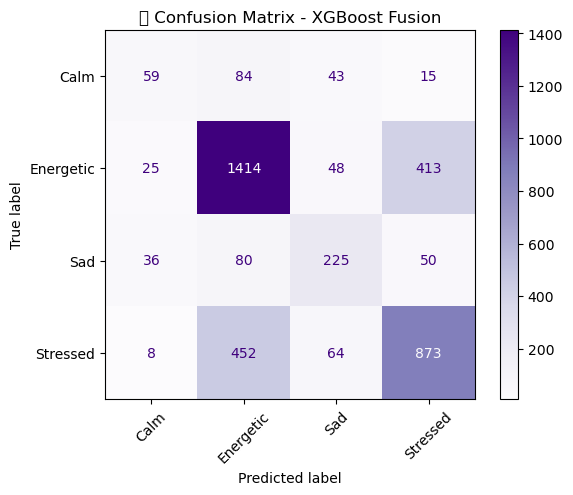

In [108]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt

sample_weights_fusion = compute_sample_weight(class_weight='balanced', y=y_train_encoded)



param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': [3, 5, 7, 10],
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5]
}


xgb_meta = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)


random_search = RandomizedSearchCV(
    estimator=xgb_meta,
    param_distributions=param_dist,
    n_iter=100,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
    random_state=42
)


random_search.fit(fusion_train, y_train_encoded, sample_weight=sample_weights_fusion)


best_xgb_meta = random_search.best_estimator_
fusion_pred = best_xgb_meta.predict(fusion_test)


print("\n🔗 LATE FUSION (XGBoost)")
print("✅ Best Parameters:", random_search.best_params_)
print("✅ Accuracy:", accuracy_score(y_test_encoded, fusion_pred))

print("\n📊 Classification Report:")
print(classification_report(y_test_encoded, fusion_pred, target_names=le.classes_))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test_encoded, fusion_pred, display_labels=le.classes_, cmap='Purples', xticks_rotation=45
)
plt.title("🎯 Confusion Matrix - XGBoost Fusion")
plt.show()


SAMPLING 

Fitting 3 folds for each of 100 candidates, totalling 300 fits


/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:37] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:45] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:18:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



...

/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:08] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:15] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:22] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.



/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:30] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/yeliz/anaconda3/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:19:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔗 LATE FUSION (XGBoost + SMOTE)
✅ Best Parameters: {'colsample_bytree': 0.6872700594236812, 'gamma': 0, 'learning_rate': 0.06503043695984914, 'max_depth': 10, 'min_child_weight': 1, 'n_estimators': 120, 'subsample': 0.6624074561769746}
✅ Accuracy: 0.6610953972743636
🔍 Sınıf dağılımı (SMOTE öncesi):
Calm: 805
Energetic: 7599
Sad: 1562
Stressed: 5588

✅ Sınıf dağılımı (SMOTE sonrası):
Calm: 7599
Energetic: 7599
Sad: 7599
Stressed: 7599

📊 Classification Report:
              precision    recall  f1-score   support

        Calm       0.46      0.29      0.36       201
   Energetic       0.70      0.74      0.72      1900
         Sad       0.59      0.58      0.58       391
    Stressed       0.65      0.62      0.64      1397

    accuracy                           0.66      3889
   macro avg       0.60      0.56      0.57      3889
weighted avg       0.66      0.66      0.66      3889



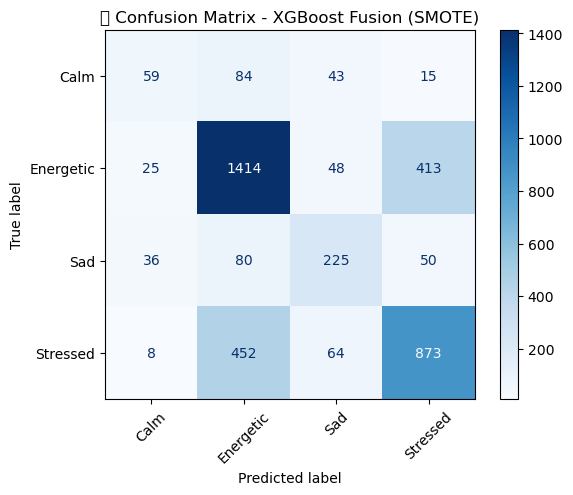

In [105]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt


sm = SMOTE(random_state=42)
fusion_train_resampled, y_train_resampled = sm.fit_resample(fusion_train, y_train_encoded)


param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': [3, 5, 7, 10],
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.5, 0.5),
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5]
}


xgb_meta = XGBClassifier(
    objective='multi:softmax',
    num_class=len(le.classes_),
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)


random_search = RandomizedSearchCV(
    estimator=xgb_meta,
    param_distributions=param_dist,
    n_iter=100,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
    random_state=42
)


random_search.fit(fusion_train_resampled, y_train_resampled)


best_xgb_meta = random_search.best_estimator_
fusion_pred = best_xgb_meta.predict(fusion_test)

print("\n🔗 LATE FUSION (XGBoost + SMOTE)")
print("✅ Best Parameters:", random_search.best_params_)
print("✅ Accuracy:", accuracy_score(y_test_encoded, fusion_pred))


original_counts = np.bincount(y_train_encoded)
print("🔍 Sınıf dağılımı (SMOTE öncesi):")
for idx, count in enumerate(original_counts):
    print(f"{le.classes_[idx]}: {count}")
    
    

resampled_counts = np.bincount(y_train_resampled)
print("\n✅ Sınıf dağılımı (SMOTE sonrası):")
for idx, count in enumerate(resampled_counts):
    print(f"{le.classes_[idx]}: {count}")


print("\n📊 Classification Report:")
print(classification_report(y_test_encoded, fusion_pred, target_names=le.classes_))


disp = ConfusionMatrixDisplay.from_predictions(
    y_test_encoded, fusion_pred, display_labels=le.classes_, cmap='Blues', xticks_rotation=45
)
plt.title("🎯 Confusion Matrix - XGBoost Fusion (SMOTE)")
plt.show()


CATBOOST

Fitting 3 folds for each of 25 candidates, totalling 75 fits

🔗 LATE FUSION (CatBoost)
✅ Best Parameters: {'bagging_temperature': 0.3745401188473625, 'border_count': 124, 'depth': 6, 'iterations': 171, 'l2_leaf_reg': 6.387926357773329, 'learning_rate': 0.05680559213273095}
✅ Accuracy: 0.65312419645153

📊 Classification Report:
              precision    recall  f1-score   support

        Calm       1.00      0.01      0.03       201
   Energetic       0.67      0.76      0.71      1900
         Sad       0.59      0.58      0.58       391
    Stressed       0.65      0.62      0.64      1397

    accuracy                           0.65      3889
   macro avg       0.73      0.49      0.49      3889
weighted avg       0.67      0.65      0.64      3889



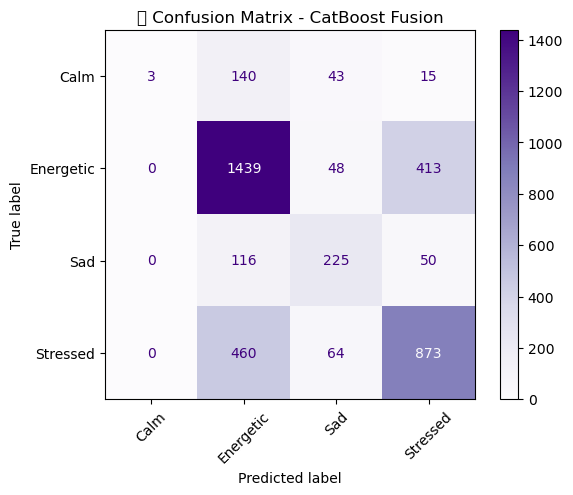

In [106]:
from catboost import CatBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt


param_dist = {
    'iterations': randint(100, 400),
    'learning_rate': uniform(0.01, 0.3),
    'depth': randint(4, 10),
    'l2_leaf_reg': uniform(1, 9),
    'bagging_temperature': uniform(0, 1),
    'border_count': randint(32, 255)
}


cat_meta = CatBoostClassifier(
    loss_function='MultiClass',
    verbose=0,
    random_state=42
)

# 📌 3. RandomizedSearchCV
random_search_cat = RandomizedSearchCV(
    estimator=cat_meta,
    param_distributions=param_dist,
    n_iter=25,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2,
    random_state=42
)


random_search_cat.fit(fusion_train, y_train_encoded)


best_cat_meta = random_search_cat.best_estimator_
fusion_pred_cat = best_cat_meta.predict(fusion_test)


print("\n🔗 LATE FUSION (CatBoost)")
print("✅ Best Parameters:", random_search_cat.best_params_)
print("✅ Accuracy:", accuracy_score(y_test_encoded, fusion_pred_cat))

print("\n📊 Classification Report:")
print(classification_report(y_test_encoded, fusion_pred_cat, target_names=le.classes_))

disp = ConfusionMatrixDisplay.from_predictions(
    y_test_encoded, fusion_pred_cat, display_labels=le.classes_, cmap='Purples', xticks_rotation=45
)
plt.title("🎯 Confusion Matrix - CatBoost Fusion")
plt.show()


ANALYSIS

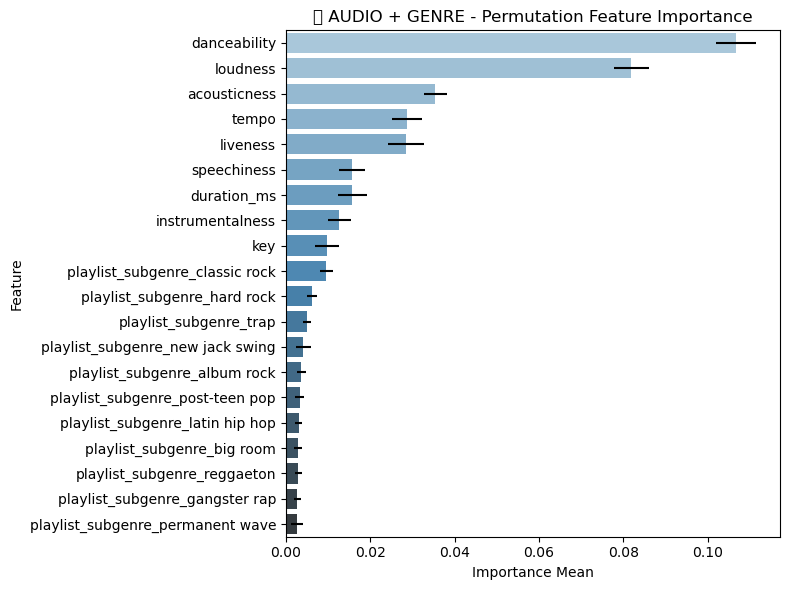

In [16]:
from sklearn.inspection import permutation_importance
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


result_audio = permutation_importance(xgb_audio, X_audio_test, y_test_encoded, n_repeats=10, random_state=42, scoring='accuracy')

audio_df = pd.DataFrame({
    'Feature': X_audio_test.columns,
    'Importance Mean': result_audio.importances_mean,
    'Importance Std': result_audio.importances_std
}).sort_values(by="Importance Mean", ascending=False).head(20)


plt.figure(figsize=(8,6))
sns.barplot(data=audio_df, x='Importance Mean', y='Feature', xerr=audio_df['Importance Std'], palette='Blues_d')
plt.title("🎧 AUDIO + GENRE - Permutation Feature Importance")
plt.tight_layout()
plt.show()


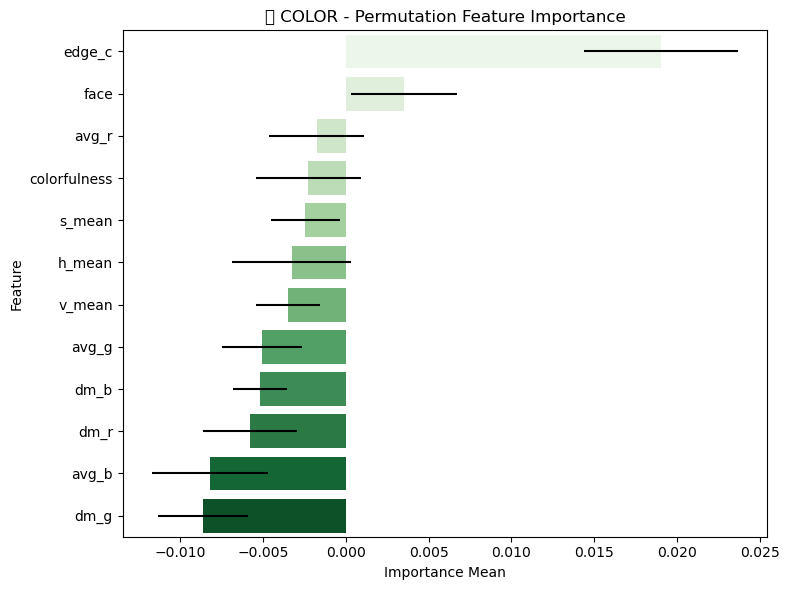

In [18]:
result_color = permutation_importance(rf_color, X_color_test, y_test_encoded, n_repeats=10, random_state=42, scoring='accuracy')

color_df = pd.DataFrame({
    'Feature': X_color_test.columns,
    'Importance Mean': result_color.importances_mean,
    'Importance Std': result_color.importances_std
}).sort_values(by="Importance Mean", ascending=False).head(20)

plt.figure(figsize=(8,6))
sns.barplot(data=color_df, x='Importance Mean', y='Feature', xerr=color_df['Importance Std'], palette='Greens')
plt.title("🎨 COLOR - Permutation Feature Importance")
plt.tight_layout()
plt.show()


In [111]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def fusion_feature_class_contribution(model, X_test, y_test, class_names):
    base_pred = model.predict(X_test)
    base_report = classification_report(y_test, base_pred, target_names=class_names, output_dict=True)
    base_f1 = {cls: base_report[cls]['f1-score'] for cls in class_names}

    result_matrix = pd.DataFrame(0.0, index=class_names, columns=X_test.columns)

    for col in X_test.columns:
        X_temp = X_test.copy()
        X_temp[col] = 0  # Özelliği sıfırla
        pred = model.predict(X_temp)
        report = classification_report(y_test, pred, target_names=class_names, output_dict=True)
        
        for cls in class_names:
            f1_diff = base_f1[cls] - report[cls]['f1-score']
            result_matrix.loc[cls, col] = round(f1_diff, 4)
    
    return result_matrix


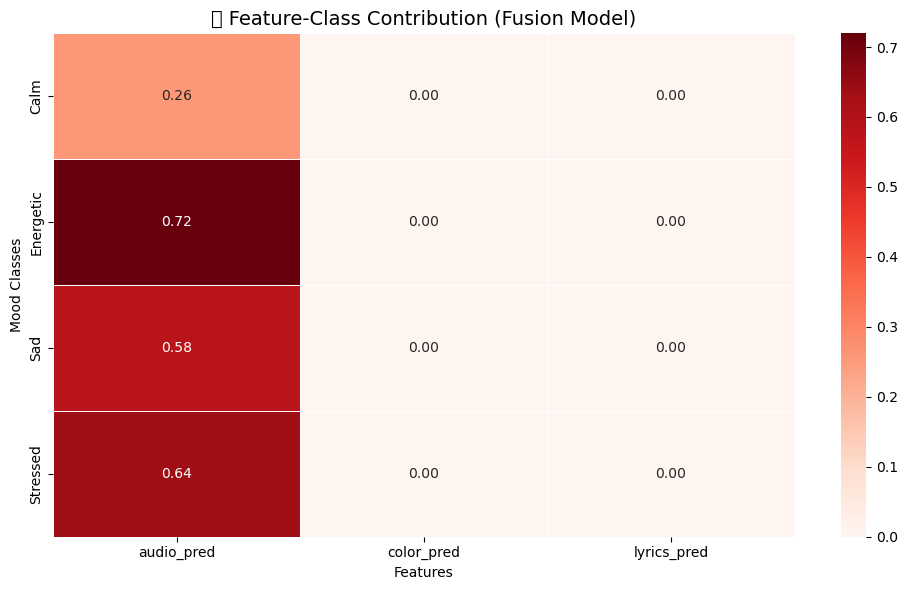

In [112]:

# Sonra fonksiyonu buna uygula:
fusion_contrib_df = fusion_feature_class_contribution(best_xgb_meta, fusion_test_df, y_test_encoded, le.classes_)

# Görselleştir
plt.figure(figsize=(10, 6))
sns.heatmap(fusion_contrib_df, cmap="Reds", annot=True, fmt=".2f", linewidths=0.5)
plt.title("🎯 Feature-Class Contribution (Fusion Model)", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Mood Classes")
plt.tight_layout()
plt.show()


In [38]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def color_feature_class_contribution(model, X_test, y_test, class_names):
    base_pred = model.predict(X_test)
    base_report = classification_report(y_test, base_pred, target_names=class_names, output_dict=True)
    base_f1 = {cls: base_report[cls]['f1-score'] for cls in class_names}

    result_matrix = pd.DataFrame(0.0, index=class_names, columns=X_test.columns)

    for col in X_test.columns:
        X_temp = X_test.copy()
        X_temp[col] = 0  
        pred = model.predict(X_temp)
        report = classification_report(y_test, pred, target_names=class_names, output_dict=True)
        
        for cls in class_names:
            f1_diff = base_f1[cls] - report[cls]['f1-score']
            result_matrix.loc[cls, col] = round(f1_diff, 4)
    
    return result_matrix


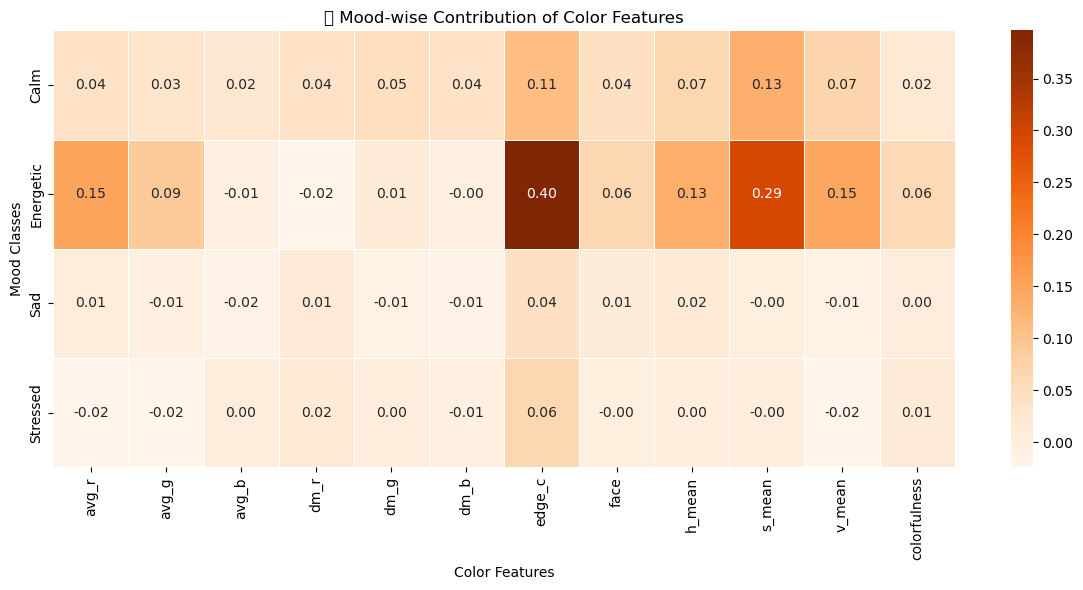

In [110]:

X_color_test_df = pd.DataFrame(X_color_test, columns=cover_cols)

# Analizi uygula
color_contrib_df = color_feature_class_contribution(rf_color, X_color_test_df, y_test_encoded, le.classes_)

# 🎨 Heatmap ile göster
plt.figure(figsize=(12, 6))
sns.heatmap(color_contrib_df, cmap="Oranges", annot=True, fmt=".2f", linewidths=0.5)
plt.title("🎨 Mood-wise Contribution of Color Features")
plt.xlabel("Color Features")
plt.ylabel("Mood Classes")
plt.tight_layout()
plt.show()


In [40]:
def audio_feature_class_contribution(model, X_test, y_test, class_names):
    from sklearn.metrics import classification_report
    import pandas as pd

    base_pred = model.predict(X_test)
    base_report = classification_report(y_test, base_pred, target_names=class_names, output_dict=True)
    base_f1 = {cls: base_report[cls]['f1-score'] for cls in class_names}

    result_matrix = pd.DataFrame(0.0, index=class_names, columns=X_test.columns)

    for col in X_test.columns:
        X_temp = X_test.copy()
        X_temp[col] = 0  
        pred = model.predict(X_temp)
        report = classification_report(y_test, pred, target_names=class_names, output_dict=True)
        
        for cls in class_names:
            f1_diff = base_f1[cls] - report[cls]['f1-score']
            result_matrix.loc[cls, col] = round(f1_diff, 4)
    
    return result_matrix


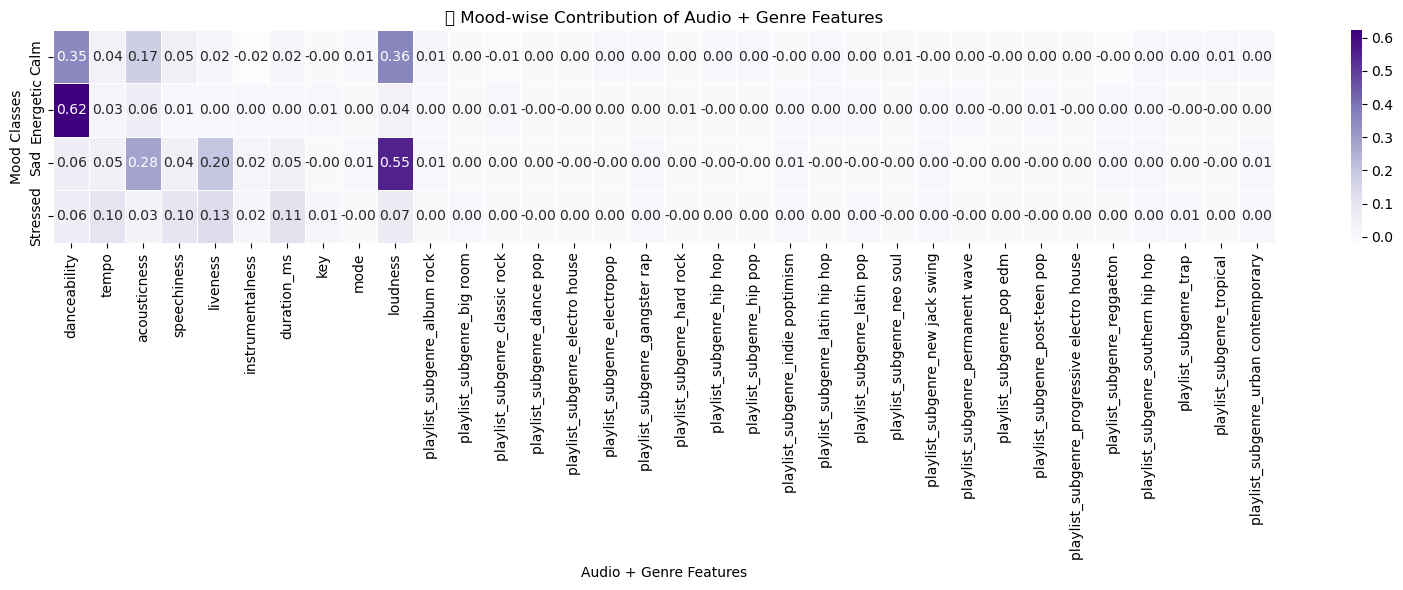

In [41]:

X_audio_test_df = pd.DataFrame(X_audio_test, columns=audio_cols + genre_cols)


audio_contrib_df = audio_feature_class_contribution(xgb_audio, X_audio_test_df, y_test_encoded, le.classes_)


import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
sns.heatmap(audio_contrib_df, cmap="Purples", annot=True, fmt=".2f", linewidths=0.4)
plt.title("🎧 Mood-wise Contribution of Audio + Genre Features")
plt.xlabel("Audio + Genre Features")
plt.ylabel("Mood Classes")
plt.tight_layout()
plt.show()


In [45]:
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


In [46]:

scores = {
    'Modality': ['Audio+Genre', 'Lyrics', 'Color'],
    'Accuracy': [
        accuracy_score(y_test_encoded, pred_audio),
        accuracy_score(y_test_encoded, pred_lyrics),
        accuracy_score(y_test_encoded, pred_color)
    ],
    'Macro F1': [
        f1_score(y_test_encoded, pred_audio, average='macro'),
        f1_score(y_test_encoded, pred_lyrics, average='macro'),
        f1_score(y_test_encoded, pred_color, average='macro')
    ]
}


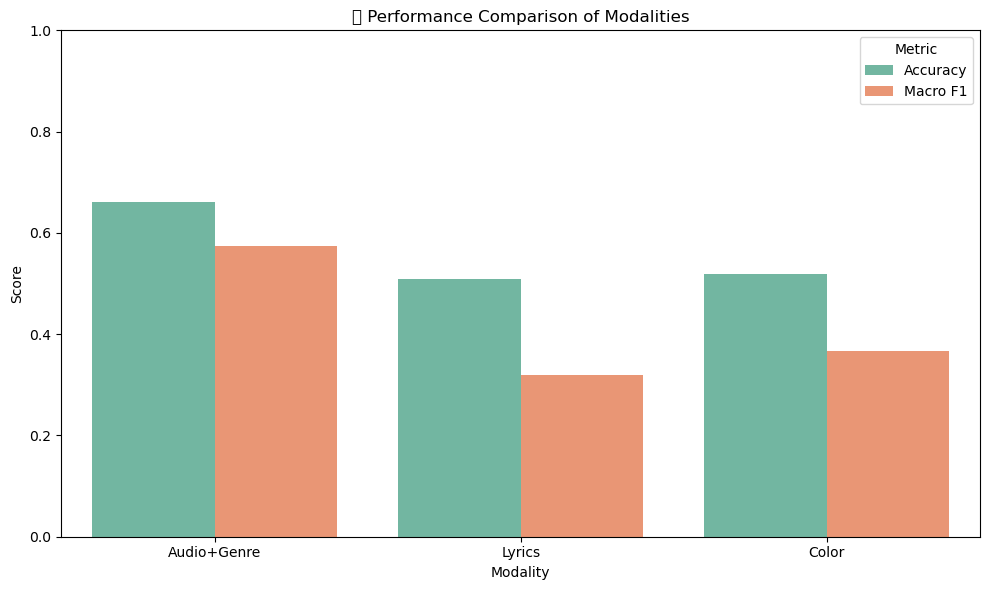

In [47]:
import pandas as pd


df_scores = pd.DataFrame(scores)


plt.figure(figsize=(10, 6))
sns.barplot(data=df_scores.melt(id_vars='Modality'), x='Modality', y='value', hue='variable', palette='Set2')
plt.title('🎯 Performance Comparison of Modalities')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


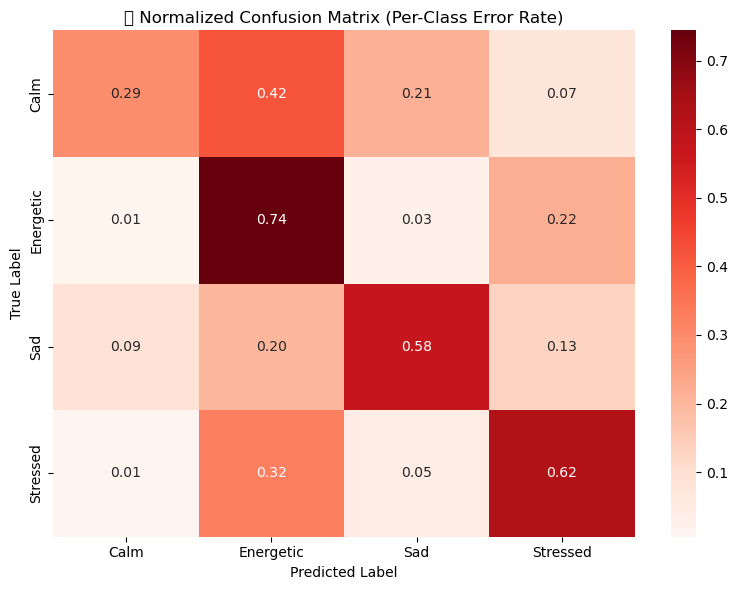

In [55]:
import seaborn as sns
import pandas as pd
import numpy as np


cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
df_cm = pd.DataFrame(cm_normalized, index=le.classes_, columns=le.classes_)

plt.figure(figsize=(8, 6))
sns.heatmap(df_cm, annot=True, cmap="Reds", fmt=".2f")
plt.title("🔍 Normalized Confusion Matrix (Per-Class Error Rate)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()
